In [1]:
# Mini-trabalho 1 - DAA
# Autores: Aluno n.º 122123 Rodrigo Delaunay e Aluno n.º 110337 Pedro Clemente

import numpy as np
import random as rd
import heapq

# Retirado da Semana 6 DAA 2.º Semestre 2024/2025. Únicas alterações registadas foram alterações de comentários a explicar o código. Preservou-se
# somente comentários mais específicos relativamente ao funcionamento do código.
#
# Classes Vertice, Aresta e Grafo para desenho da Digrafo
# Class Vertice
class Vertex:
   
    def __init__(self, vertex_id):
        self._vertex_id = vertex_id  # Id do vértice (elemento a inserir no grafo)

    def __hash__(self):
        return hash(self._vertex_id)  # devolve o hash do elemento

    def __str__(self):
        return 'v{0}'.format(self._vertex_id)

    def __eq__(self, vertex):
        return self._vertex_id == vertex._vertex_id  # Deve-se garantir que: se hash(vertex)==hash(self), entao vertex==self

    def __lt__(self, vertex):
        return self._vertex_id < vertex._vertex_id

    def __le__(self, vertex):
        return self._vertex_id <= vertex._vertex_id

    def __gt__(self, vertex):
        return self._vertex_id > vertex._vertex_id

    def __ge__(self, vertex):
        return self._vertex_id >= vertex._vertex_id

    def vertex_id(self):
        return self._vertex_id

# Class Edge
class Edge:

    def __init__(self, vertex_1, vertex_2, weight):
        self._vertex_1 = vertex_1
        self._vertex_2 = vertex_2
        self._weight = weight

    def __hash__(self):
        return hash((self._vertex_1, self._vertex_2))

    def __str__(self):
        return 'e({0},{1})w={2}'.format(self._vertex_1, self._vertex_2, self._weight)

    def __eq__(self, other):
        # define igualdade de duas arestas (deve ser consistente com a função hash)
        return self._vertex_1 == other._vertex_1 and self._vertex_2 == other._vertex_2

    def endpoints(self):
        return (self._vertex_1, self._vertex_2)

    def cost(self):
        return self._weight

    def opposite(self, vertex):
        if vertex == self._vertex_1:
            return self._vertex_2
        elif vertex == self._vertex_2:
            return self._vertex_1
        else:
            return None


class Graph:
    def __init__(self):
        self._adjancencies = {}  # dicionário que associa o par chave-valor: <Vertex v, Mapa de adjacências de v>
        self._vertices = {}  # dicionário que associa o par: <id do vértice, objeto Vertex correspondente>
        self._n = 0  # número de vértices do grafo
        self._m = 0  # número de arestas do grafo

    def __str__(self):
        if self._n == 0:
            ret = "DAA-Graph: <empty>\n"
        else:
            ret = "DAA-Graph:\n"
            for vertex in self._adjancencies.keys():
                # ret += "vertex-"
                ret += str(vertex) + ": "
                for edge in self.incident_edges(vertex.vertex_id()):
                    ret += str(edge) + "; "
                ret += "\n"
        return ret

    def is_directed(self):
        return False

    def order(self):
        return self._n

    def size(self):
        return self._m

    def has_vertex(self, vertex_id):
        return vertex_id in self._vertices

    def has_edge(self, u_id, v_id):
        if not self.has_vertex(u_id) or not self.has_vertex(v_id):
            return False
        else:
            vertex_u = self._vertices[u_id]
            vertex_v = self._vertices[v_id]
            return vertex_v in self._adjancencies[vertex_u]

    def insert_vertex(self, vertex_id):
        if not self.has_vertex(vertex_id):
            vertex = Vertex(vertex_id)  # instancia um objeto do tipo Vertex
            self._vertices[vertex_id] = vertex  # insere o novo vértice no dicionário de vertices
            self._adjancencies[vertex] = {}  # inicializa o mapa de adjacências deste vértice a vazio
            self._n += 1  # mais um vértice no grafo

    def insert_edge(self, u_id, v_id, weight=0):
        if not self.has_vertex(u_id):
            self.insert_vertex(u_id)  # insere novo vertex e atualiza n
        if not self.has_vertex(v_id):
            self.insert_vertex(v_id)  # insere novo vertex e atualiza n
        if not self.has_edge(u_id, v_id):
            self._m += 1  # atualiza m apenas se a aresta ainda não existir no grafo
        else:
            print(f"Existing edge {u_id} and {v_id}. Will only update weight")
        vertex_u = self._vertices[u_id]  # acede ao objeto Vertex associado a u_id
        vertex_v = self._vertices[v_id]  # acede ao objeto Vertex associado a v_id
        e = Edge(vertex_u, vertex_v, weight)
        self._adjancencies[vertex_u][vertex_v] = e  # coloca v nas adjacências de u
        self._adjancencies[vertex_v][
            vertex_u] = e  # e u nas adjacências de v (para facilitar a procura de todas as arestas incidentes num vértice)

    def degree(self, vertex_id):
        return len(self._adjancencies[self._vertices[vertex_id]])

    def get_vertex(self, vertex_id):
        return None if not self.has_vertex(vertex_id) else self._vertices[vertex_id]

    def get_edge(self, u_id, v_id):
        if not self.has_edge(u_id, v_id):
            return None
        else:
            vertex_u = self._vertices[u_id]
            vertex_v = self._vertices[v_id]
            return self._adjancencies[vertex_u][vertex_v]

    def vertices(self):
        return self._vertices.values()

    def edges(self):
        seen = {}  # evita a repetição de arestas no grafo não orientado
        for adj_map in self._adjancencies.values():
            for edge in adj_map.values():
                if edge not in seen:
                    yield edge
                seen[edge] = True

    def incident_edges(self, vertex_id):
        vertex = self._vertices[vertex_id]
        for edge in self._adjancencies[vertex].values():  # para todas as arestas incidentes em v:
            yield edge

    def has_neighbors(self, vertex_id):
        if not self.has_vertex(vertex_id):
            return False
        return self.degree(vertex_id) == 0

    def remove_vertex(self, vertex_id):
        # Passo 1: remover todas as arestas do vértice dado
        # Passo 2: remover todas as arestas incidentes em vertex_id dos mapas de outros vertices
        # Passo 3: remover o vértice com id vertex_id do grafo
        # Passo 4: decrementa contador de vértices
        if self.has_vertex(vertex_id):
            lst_copied = list(self.incident_edges(
                vertex_id))  # copia para a lista para evitar erros de concorrência (remove enquanto itera na lista)
            for edge in lst_copied:
                x, y = edge.endpoints()
                self.remove_edge(x.vertex_id(), y.vertex_id())  # (Passos 1 e 2)
            del self._adjancencies[self._vertices[vertex_id]]  # (Passo 3 - remove do dicionário de adjacências)
            del self._vertices[vertex_id]  # (Passo 3 - remove do dicionário de vértices)
            self._n -= 1  # (Passo 4 - decrementa contador)

    def remove_edge(self, u_id, v_id):
        if self.has_edge(u_id, v_id):
            vertex_u = self._vertices[u_id]
            vertex_v = self._vertices[v_id]
            del self._adjancencies[vertex_u][vertex_v]
            if vertex_u != vertex_v:  # laços são removidos apenas uma vez
                del self._adjancencies[vertex_v][vertex_u]
            self._m -= 1

#  ### Classe DiGrafo
class DiGraph(Graph):
    '''Classe que representa um grafo orientado. Herda da classe Graph.'''
    def __init__(self):
        super().__init__()
        self._in_adjancencies = {}  # dicionário com chave vértice e valor mapa de adjacências das arestas de entrada

    def is_directed(self):
        return True

    def __repr__(self):
        if self._n == 0:
            ret = "DAA-DiGraph out-Representation: <empty>\n"
            ret += "DAA-DiGraph in-Representation: <empty>\n"
        else:
            ret = "DAA-DiGraph out-Representation:\n"
            for vertex in self._adjancencies.keys():
                ret += str(vertex)
                ret += " out-deg " + str(self.out_degree(vertex.vertex_id())) + ":\t"
                for edge in self.successors(vertex.vertex_id()):
                    ret += str(edge) + "; "
                ret += "\n"
            ret += "DAA-DiGraph in-Representation:\n"
            for vertex in self._in_adjancencies.keys():
                ret += str(vertex)
                ret += " in-deg " + str(self.in_degree(vertex.vertex_id())) + ":\t"
                for edge in self.predecessors(vertex.vertex_id()):
                    ret += str(edge) + "; "
                ret += "\n"
        return ret

    def __str__(self):
        '''Devolve a representação do grafo em string.'''
        if self._n == 0:
            ret = "DAA-DiGraph: <empty>\n"
        else:
            ret = "DAA-Graph:\n"
            for vertex in self._adjancencies.keys():
                # ret += "vertex-"
                ret += str(vertex) + ": "
                for edge in self.successors(vertex.vertex_id()):
                    ret += str(edge) + "; "
                ret += "\n"
        return ret

    def is_successor(self, u_id, v_id):
        """Verifica se o nó u é sucessor do vértice v no grafo."""
        return super().has_edge(v_id, u_id)

    def is_predecessor(self, u_id, v_id):
        """ Verifica se o vértice u é antecessor do vértice v no grafo.
            Corresponde ao método super().has_edge(u,v). """
        return super().has_edge(u_id, v_id)

    def insert_vertex(self, vertex_id):
        '''Insere um novo nó com id vertex_id.'''
        super().insert_vertex(vertex_id)  # inicializa o mapa dos arcos de saída (_adjancencies)
        vertex = self._vertices[vertex_id]
        self._in_adjancencies[vertex] = {}  # inicializa o mapa dos arcos de entrada (_in_adjancencies)

    def insert_edge(self, u_id, v_id, weight=0):
        ''' Cria e insere um novo arco entre u_id e v_id com peso weight.
            Se o arco já existe no grafo, atualiza-se o seu peso.
            Também insere os nós u_id e v_id, caso não existam.'''
        if not self.has_vertex(u_id):
            self.insert_vertex(u_id)  # insere novo vertex e atualiza n
        if not self.has_vertex(v_id):
            self.insert_vertex(v_id)  # insere novo vertex e atualiza n
        if not self.has_edge(u_id, v_id):
            self._m += 1  # atualiza m apenas se a aresta ainda não existir no grafo
        else:
            print(f"Existing edge {u_id} and {v_id}. Will only update weight")
        vertex_u = self._vertices[u_id]
        vertex_v = self._vertices[v_id]
        e = Edge(vertex_u, vertex_v, weight)
        self._adjancencies[vertex_u][vertex_v] = e  # coloca v nas adjacências de u
        self._in_adjancencies[vertex_v][
            vertex_u] = e  # e u nas adjacências de v (para facilitar a procura de todas as arestas incidentes num vértice)

    def out_degree(self, vertex_id):
        return len(self._adjancencies[self._vertices[vertex_id]])  # Verifica o tamanho do mapa de saída de v

    def in_degree(self, vertex_id):
        return len(self._in_adjancencies[self._vertices[vertex_id]])  # Verifica o tamanho do mapa de entrade de v

    def edges(self):
        for adj_map in self._adjancencies.values():
            for edge in adj_map.values():
                yield edge

    def successors(self, vertex_id):  # igual ao super().incident_edges(v)
        return self.incident_edges(vertex_id)

    def predecessors(self, vertex_id):
        vertex = self._vertices[vertex_id]
        for edge in self._in_adjancencies[vertex].values():  # para todas os arcos que entram no vértice
            yield edge

    def remove_edge(self, u_id, v_id):
        if self.has_edge(u_id, v_id):
            vertex_u = self._vertices[u_id]
            vertex_v = self._vertices[v_id]
            del self._adjancencies[vertex_u][vertex_v]
            del self._in_adjancencies[vertex_v][vertex_u]
            self._m -= 1

    def remove_vertex(self, vertex_id):
        # Passo 1: remover todos os arcos que saem do vértice dado
        # Passo 2: remover todos os arcos que entram no vértice dado
        # Passo 3: remover o vértice do grafo
        if self.has_vertex(vertex_id):
            lst_out = list(self.successors(vertex_id))  # copia para a lista para evitar erros de concorrência
            for edge in lst_out:
                x, y = edge.endpoints()
                self.remove_edge(x.vertex_id(), y.vertex_id())  # (Passos 1)
            lst_in = list(self.predecessors(vertex_id))  # copia para a lista para evitar erros de concorrência
            for edge in lst_in:
                x, y = edge.endpoints()
                self.remove_edge(x.vertex_id(), y.vertex_id())  # (Passos 2)
            del self._adjancencies[self._vertices[vertex_id]]  # (Passo 3 - remove do dicionário de saídas)
            del self._in_adjancencies[self._vertices[vertex_id]]  # (Passo 3 - remove do dicionário de entradas)
            del self._vertices[vertex_id]  # (Passo 3 - remove do dicionário de vértices)
            self._n -= 1


In [2]:
class DAGSeamCarving:
    def __init__(self, energy_matrix):
        self.energy_matrix = energy_matrix #
        self.height, self.width = energy_matrix.shape # altura e largura matriz energia
        self.graph = DiGraph() # Cria um grafo direcionado acíclico (DAG) para o Seam Carving

    def build_dag(self):
        """Constrói o grafo direcionado acíclico (DAG) para o Seam Carving."""
        source = "source"
        sink = "sink"
        self.graph.add_vertex(source) #adicionar nó source
        self.graph.add_vertex(sink) # adicionar nó sink

        # adiciona os nós e arestas
        for y in range(self.height):
            for x in range(self.width):
                node = (y, x)
                self.graph.add_vertex(node) # adicionar nó (y,x) ao grafo
                if y == 0:
                    self.graph.add_edge(source, node, self.energy_matrix[y, x]) # adicionar aresta do nó source para o nó (y,x) com peso energia
                if y < self.height - 1: # se não for a última linha
                    for dx in [-1, 0, 1]:
                        nx = x + dx
                        if 0 <= nx < self.width: # verificar se a coluna está dentro dos limites
                            next_node = (y + 1, nx) # nó da linha seguinte
                            self.graph.add_edge(node, next_node, self.energy_matrix[y + 1, nx]) # adicionar aresta do nó (y,x) para o nó da linha seguinte com peso energia
                if y == self.height - 1: # se for a última linha
                    self.graph.add_edge(node, sink, 0)

        return self.graph


In [3]:
import numpy as np
import heapq

class SeamCarving:
    def __init__(self, image):
        self.image = image.astype(np.int32)
        self.height, self.width, _ = image.shape
        self.energy = self._calculate_energy()
        self.adj = self._build_adjacency_list()

    def _calculate_energy(self):
        energy = np.zeros((self.height, self.width), dtype=np.float64)
        for y in range(1, self.height - 1):
            for x in range(1, self.width - 1):
                dx2 = np.sum((self.image[y, x + 1] - self.image[y, x - 1]) ** 2)
                dy2 = np.sum((self.image[y + 1, x] - self.image[y - 1, x]) ** 2)
                energy[y, x] = np.sqrt(dx2 + dy2)
        energy[0, :] = energy[-1, :] = energy[:, 0] = energy[:, -1] = 1e6
        return energy

    def _build_adjacency_list(self):
        #Lista de adjacências adj[y][x] -> lista de (ny, nx, peso)
        adj = [[[] for _ in range(self.width)] for _ in range(self.height)]
        for y in range(self.height - 1):  # Última linha não tem vizinhos para baixo portanto tira 1
            for x in range(self.width):
                for dx in [-1, 0, 1]:
                    nx = x + dx
                    ny = y + 1
                    if 0 <= nx < self.width:
                        peso = self.energy[ny, nx]
                        adj[y][x].append((ny, nx, peso))
        return adj

    def find_vertical_seam(self):
        dist = {}
        prev = {}
        heap = []

        for x in range(self.width):
            node = (0, x)
            dist[node] = self.energy[0, x]
            heapq.heappush(heap, (dist[node], node))

        while heap:
            cost, u = heapq.heappop(heap)
            y, x = u
            for ny, nx, peso in self.adj[y][x]:
                v = (ny, nx)
                alt = cost + peso
                if v not in dist or alt < dist[v]:
                    dist[v] = alt
                    prev[v] = u
                    heapq.heappush(heap, (alt, v))

        last_row_nodes = [(self.height - 1, x) for x in range(self.width)]
        end_node = min(last_row_nodes, key=lambda n: dist.get(n, float('inf')))

        seam = []
        while end_node in prev:
            seam.append(end_node)
            end_node = prev[end_node]
        seam.append(end_node)
        seam.reverse()
        return seam
    
    
    # Remover a costura vertical da imagem
    def remove_vertical_seam(self, seam): 
        new_image = np.zeros((self.height, self.width - 1, 3), dtype=np.int32)
        for y in range(self.height):
            x = seam[y][1]
            new_image[y, :x, :] = self.image[y, :x, :]
            if x < self.width - 1:  # Só copia se houver pixels à direita
                new_image[y, x:, :] = self.image[y, x+1:, :]
        self.image = new_image
        self.height, self.width, _ = self.image.shape
        self.energy = self._calculate_energy()
        self.adj = self._build_adjacency_list()

    # Adicionar a costura vertical à imagem
    def get_image(self):
        return self.image.astype(np.uint8)

    def set_image(self, new_image):
        self.image = new_image.astype(np.int32)
        self.height, self.width, _ = self.image.shape
        self.energy = self._calculate_energy()
        self.adj = self._build_adjacency_list()



Memória total usada (em bytes): 2227888


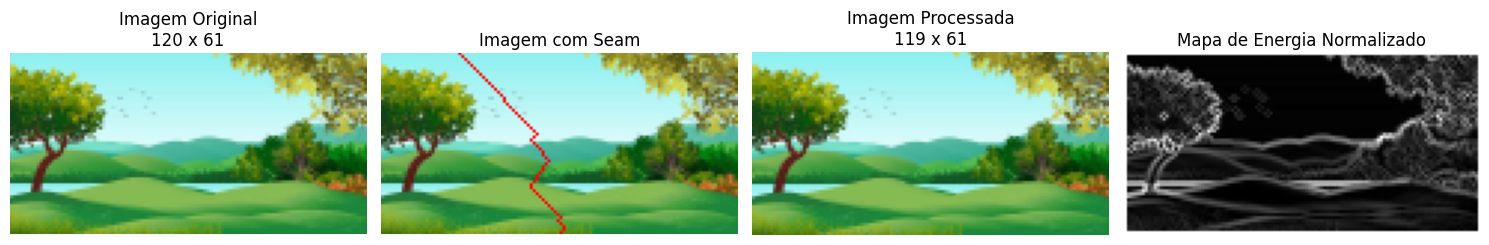

In [4]:
from PIL import Image
from sys import getsizeof
import numpy as np
import matplotlib.pyplot as plt
import os

# Pasta onde o presente programa está localizado
current_directory = os.getcwd()

image_path = os.path.join(current_directory, "test_small.png") # ir buscar img

# Carregar a imagem
image = np.array(Image.open(image_path).convert("RGB"))
 
seam_carving = SeamCarving(image) #objeto SeamCarving

energy_map = seam_carving._calculate_energy() #mapa energia

vertical_seam = seam_carving.find_vertical_seam() # seam vertical

# estimar utilização memória img carregada na estrutura de dados prevista na solução SeamCarving
def estimate_memory_usage(sc):
    size = 0
    size += sc.image.nbytes
    size += sc.energy.nbytes
    size += getsizeof(sc.adj)
    for row in sc.adj:
        size += getsizeof(row)
        for cell in row:
            size += getsizeof(cell)
            for item in cell:
                size += getsizeof(item)
    return size
print("Memória total usada (em bytes):", estimate_memory_usage(seam_carving))

# 4 subplots
plt.figure(figsize=(15, 5))

# img original
plt.subplot(1, 4, 1)
plt.imshow(image)
plt.title(f"Imagem Original\n{image.shape[1]} x {image.shape[0]}")
plt.axis("off")

# img com o seam
image_with_seam = image.copy()
for y, x in vertical_seam:
    image_with_seam[y, x] = [255, 0, 0]  # vermelho

plt.subplot(1, 4, 2)
plt.imshow(image_with_seam)
plt.title("Imagem com Seam")
plt.axis("off")

# img processada (sem o seam)
seam_carving.remove_vertical_seam(vertical_seam)
processed_image = seam_carving.get_image()[:, :, :3]  # remover canal alfa

plt.subplot(1, 4, 3)
plt.imshow(processed_image)
plt.title(f"Imagem Processada\n{processed_image.shape[1]} x {processed_image.shape[0]}")
plt.axis("off")

# mapa de energia normalizado (sem bordas)
core_energy = energy_map[1:-1, 1:-1]
normalized_core = (core_energy - np.min(core_energy)) / (np.max(core_energy) - np.min(core_energy))
normalized_energy = np.ones_like(energy_map)
normalized_energy[1:-1, 1:-1] = normalized_core

plt.subplot(1, 4, 4)
plt.imshow(normalized_energy, cmap='gray') #normalizar mapa energia
plt.title("Mapa de Energia Normalizado")
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import os

# Funções de redução de largura e altura
def reduzir_largura(seam_carving, num_seams):
    print(f"Total de seams a remover na largura: {num_seams}")
    for i in range(num_seams):
        print(f"A remover seam número {i + 1} de {num_seams}...")
        seam = seam_carving.find_vertical_seam()
        seam_carving.remove_vertical_seam(seam)

def reduzir_altura(seam_carving, num_seams):
    imagem_rodada = np.rot90(seam_carving.get_image(), 1, (0, 1))  # roda imagem 90 graus
    seam_carving_rodada = SeamCarving(imagem_rodada)
    print(f"Total de seams a remover na altura: {num_seams}")
    for i in range(num_seams):
        print(f"A remover seam número {i + 1} de {num_seams}...")
        seam = seam_carving_rodada.find_vertical_seam()
        seam_carving_rodada.remove_vertical_seam(seam)
    imagem_final = np.rot90(seam_carving_rodada.get_image(), -1, (0, 1))  # rodar de volta
    seam_carving.set_image(imagem_final)

def reduzir_imagem(imagem, direcao, percentagem): #funcao para reduzir imagem. 4.1. Reduzir em largura ou altura
    seam_carving = SeamCarving(np.copy(imagem))
    if direcao == "largura": #caso input seja largura
        num_seams = int(imagem.shape[1] * percentagem) #calcular numero seams
        reduzir_largura(seam_carving, num_seams) #reduzir largura nesse numero de seams
    elif direcao == "altura":
        num_seams = int(imagem.shape[0] * percentagem)#calcular numero seams
        reduzir_altura(seam_carving, num_seams)  #reduzir altura nesse numero de seams
    else:
        raise ValueError("Direção inválida. Use 'largura' ou 'altura'.")
    return seam_carving.get_image()[:, :, :3]  # Retornar imagem RGB (sem alfa)

current_directory = os.getcwd() #caminho das imagens. deverao estar na pasta onde se corra o presente projeto.
image_path_1 = os.path.join(current_directory, "img-broadway_tower.jpg") #cfr enunciado
image_path_2 = os.path.join(current_directory, "img-brent-cox-unsplash.jpg")
 
original_image_1 = np.array(Image.open(image_path_1).convert("RGB")) #carregar imgs
original_image_2 = np.array(Image.open(image_path_2).convert("RGB"))

imagem_largura_reduzida = reduzir_imagem(original_image_1, "largura", 0.30)  # reduzir 30% largura cfr enunciado (fica 70%)
imagem_altura_reduzida = reduzir_imagem(original_image_2, "altura", 0.40)    # reduzir 40% altura cfr enunciado (fica 60%)

# resultados
plt.figure(figsize=(18, 12))  # Aumentar o tamanho da figura para acomodar 2 linhas de subplots

# Primeira linha: imagens originais
plt.subplot(2, 2, 1)  # 2 linhas, 2 colunas, primeiro subplot
plt.imshow(original_image_1)
plt.title(f"Original 1: {original_image_1.shape[1]}x{original_image_1.shape[0]}")
plt.axis("off")

plt.subplot(2, 2, 2)  # 2 linhas, 2 colunas, segundo subplot
plt.imshow(original_image_2)
plt.title(f"Original 2: {original_image_2.shape[1]}x{original_image_2.shape[0]}")
plt.axis("off")

# Segunda linha: imagens reduzidas
plt.subplot(2, 2, 3)  # 2 linhas, 2 colunas, quarto subplot
plt.imshow(imagem_largura_reduzida)
plt.title(f"Reduzida em Largura: {imagem_largura_reduzida.shape[1]}x{imagem_largura_reduzida.shape[0]}")
plt.axis("off")

plt.subplot(2, 2, 4)  # 2 linhas, 2 colunas, terceiro subplot
plt.imshow(imagem_altura_reduzida)
plt.title(f"Reduzida em Altura: {imagem_altura_reduzida.shape[1]}x{imagem_altura_reduzida.shape[0]}")
plt.axis("off")


plt.tight_layout()
plt.show()
plt.show()

Total de seams a remover na largura: 288
A remover seam número 1 de 288...
A remover seam número 2 de 288...
A remover seam número 3 de 288...
A remover seam número 4 de 288...
A remover seam número 5 de 288...
A remover seam número 6 de 288...
A remover seam número 7 de 288...
A remover seam número 8 de 288...
A remover seam número 9 de 288...
A remover seam número 10 de 288...
A remover seam número 11 de 288...
A remover seam número 12 de 288...
A remover seam número 13 de 288...


**<p align="center">Respostas às questões propostas no âmbito do Mini-trabalho</p>**

**<p align="center"> 2. Representação dos dados </p>**

- **Como está a representar a energia dos pixels no seu grafo? Qual foi o critério para esta escolha? Que tipo de grafo representa o problema em questão?**  

Considerando o problema proposto, onde o objetivo será encontrar e remover caminhos de energia mínima (seams) de uma imagem, a nossa solução utiliza o conceito de grafo direcionado e acícilo. Esta escolha deveu-se à natureza de aplicação um grafo direcionado e acíclico e a possibilidade de utilização de algoritmos eficientes de caminho verticais mínimos abordados nas aulas teóricas.

Em relação à representação da energia, a nossa solução propõe os seguintes pressupostos:
1.	A energia de cada pixel (calculado conforme equação fornecida no enunciado) deverá ser armazenada nesse próprio pixel, através do atributo energy[v];
2.	Para cada nó deverão ser criadas as três arestas direcionais referidas anteriormente, sendo que o peso das mesmas deverá ser o peso do nó destino.
Com esta solução, torna-se possível executar um algoritmo de caminho mínimo a partir do nó fonte fictício até ao destino fictício, guardando em arrays dist[] e prev[] o caminho mínimo que deverá ser posteriormente eliminado.


- **Qual é a representação computacional de grafo que está a utilizar? Por exemplo, matriz de adjacência, lista/mapa de adjacências ou uma outra alternativa?**  

Foi utilizada para a representação computacional do grafo uma lista de adjacências, onde cada nó (representado pelas coordenadas (x,y) da imagem em análise) é mapeado para uma lista de pares (vizinho e peso, que é a respetiva energia).

- **Identifique as vantagens e desvantagens da sua representação de grafo escolhida e os critérios utilizados para a sua escolha. Por exemplo, a sua escolha facilita a implementação de alguma operação específica? Ou faz com que as operações fiquem mais eficientes (em relação ao tempo e ao espaço em memória)?**

Como vantagens da representação computacional referida no parágrafo anterior destacam-se os seguintes pontos:
1. Apenas as ligações relevantes (no máximo 3 por pixel) são armazenadas. Desta forma, garante-se eficiência em termos de utilização de espaço;
2. Permite aplicar algoritmos de caminho mínimo em tempo linear em DAGs (ex: topological relaxation), garantindo eficiência temporal;
3. Facilita a visualização do caminho mínimo como uma sequência de nós (pixéis).

Como desvantagens da representação computacional referida no parágrafo anterior identificam-se os seguintes pontos:
1. Requer conversão da imagem para grafo antes de cada operação;
2. Implementações com lista de adjacência podem ter maior overhead para acesso direto (comparado a uma matriz de adjacência), mas esse não é um problema no contexto do SeamCarving.

- **Se optou por utilizar as classes Graph/Digraph fornecidas na Semana 6 para a sua solução, identifique também as possíveis modificações que teve de realizar nas classes.**  
Optámos por utilizar as classes Graph/Digraph fornecidas na Semana 6 para a nossa solução. Retirámos somente alguns comentários previamente inseridos.


**<p align="center"> 3. API Seam Carving </p>**

**<p> 3.1. Estrutura de Dados </p>**

 - **Descreva a estrutura de dados utilizada para implementar a sua API. Apresente uma estimativa do espaço de memória total utilizado pela sua aplicação para armazenar os atributos da classe SeamCarving em função das dimensões da imagem original, ou seja, largura (W) e altura (H) da imagem. Nota: Deve também apresentar uma estimativa do espaço real ocupado pela classe para a imagem fornecida para testes, test_small.png. Para isso, pode utilizar a função getsizeof() do módulo Python sys, e verificar o tamanho dos atributos do grafo construído e também de qualquer outro atributo que componha a sua implementação da classe SeamCarving.**

A estrutura de dados utilizada para implementar a API proposta na presente solução, que visa representar a imagem como um digrafo acíclico (conforme descrito anteriormente) em que cada pixel corresponde a um vértice e as arestas correspondem a pixéis vizinhos na linha anterior, foi baseada em:
1. Imagem - A imagem original é armazenada numa matriz tridimensional (self.image, int32 portanto cada elemento ocupa 4 bytes, HxWx3 sendo H height, W width e 3 os valores referentes à coloração de cada píxel, RGB);
2. Energia - Calculada em conformidade com a equação proposta no enunciado do minitrabalho, armazenada numa matriz e duas dimensões (self.energy, float64 portanto cada elemento ocupa 8 bytes, HxW);
3. Grafo (representação da vizinhança de cada nó pixel) - Lista de adjacências, onde cada pixel tem três nós vizinhança diretamente abaixo e cada tuplo contém (ny, nx, peso) sendo peso a energia calculada anteriormente. Como ny e nx são números inteiros referentes às coordenadas do nó em questão, cada um ocupará 4 bytes. Como o peso (energia) são float64, ocupam 8 bytes.

Tendo em consideração o descrito acima, a memória ocupada pela estrutura de dados proposta na solução apresentada será a seguinte (naturalmente variável conforme H e W da imagem):
| Atributo       | Fórmula   |
|----------------|-----------|
| self.image     | 12HW      |
| self.energy    | 8HW       |
| self.adj       | 48HW      |
| **Total**      | **68HW**  |

Como a imagem test_small.png tem como dimensões 120x61, deverá ocupar 68*120*61=497.760 bytes nesta solução.

Infelizmente denotámos que o getsizeof() importado de sys do Python apresentou um valor totalmente diferente (2.227.888 bytes) que acreditamos que se deva a overhead interno da linguagem Python. Todavia, verifica-se que, efetivamente, a estrutura de dados proposta acaba por ser pesada, mesmo para uma imagem de reduzida dimensão.

**<p> 3.2. Calcular a energia de uma imagem </p>**  
- **3.2.1) Implemente e teste a função auxiliar _calculate_energy() que irá calcular a energia da imagem atual.  
A função deve devolver o mapa da energia da imagem como um ndarray (numpy array).**  

Implementação efetuada em conformidade. ndarray devolvido conforme estrutura de dados referida na resposta à questão anterior.


- **3.2.2) Apresente uma análise da complexidade desta função em relação ao tempo e ao espaço extra de  
memória utilizados (em função da dimensão da imagem).**  

A função em questão percorre quase todos os píxeis da imagem (não corre as bordas) e, para cada pixel (y, x):
1. Faz duas subtrações vetoriais de tamanho 3 --> Custo O(3);
2. Eleva ao quadrado e soma os elementos --> Custo O(3);
3. Soma os dois valores e calcula a raiz quadrada --> Custo O(1).

Poderemos concordar que, portanto, cada iteração é constante (O(1)) pois todas as operações de cálculo (elementares) têm um custo fixo. O número de iterações será (H-2)x(W-2), que poderemos estimar para H x W. O custo temporal, será, portanto, O(H x W).

Em termos de uso de memória adicional, como a imagem já se encontra "carregada" antes de ser corrida esta função, o espaço adicional utilizado será somente H x W (referente à memória da matriz energy).

**<p> 3.3. Encontrar a costura de menor energia </p>** 

- **3.3.1) Descreva os passos e as modificações realizadas no grafo e/ou no algoritmo para reduzir o problema do seam carving para o problema do caminho mais curto num grafo (shortest path). Indique qual algoritmo shortest path que escolheu implementar e o motivo da sua escolha.**  

Para reduzir o problema do SeamCarving ao problema do caminho mais curto num grafo, o dígrafo direcional acíclico concebido com base na imagem foi representado da seguinte forma:
1.	Cada pixel da imagem é representado por um nó do grafo;
2.	Existem arestas direcionadas dos pixéis de uma linha para a linha imediatamente abaixo, respeitantes à vizinhança de 3 pixéis nas seguintes direções: (i) abaixo-esquerda; (ii) abaixo; (iii) abaixo-direita.
3.	Como as arestas só têm direção para baixo, não haverão ciclos. Daí o grafo ser acícilico;
4.	Considerou-se a inserção de um nó fictício de origem e um nó fictício de destino, sendo que os mesmos se conectam a todos os nós da primeira e última linha respetivamente.

O algoritmo escolhido para encontrar o caminho mais curto foi o algoritmo de Dijkstra, devido à sua eficiência em grafos com pesos não negativos e à sua simplicidade de implementação. Este algoritmo permitiu o cálculo do caminho de menor custo desde o nó fictício inicial até ao final (de destino), garantindo a identificação da costura de menor energia.  

- **3.3.2) Implemente e teste o método find_vertical_seam() que deverá encontrar o caminho de menor energia.**  

O método find_vertical_seam() foi implementado utilizando o algoritmo de Dijkstra, conforme descrito anteriormente. Efetuou-se o teste e identificou-se a Seam, posteriormente, com a cor vermelha. 

- **3.3.3) Apresente uma análise completa da complexidade do seu algoritmo em função da dimensão da imagem, e compare-a com a complexidade de outras versões do algoritmo shortest path.**  

A complexidade do algoritmo de Dijkstra depende da estrutura de dados utilizada para a fila de prioridade. Na nossa implementação, utilizámos um heap binário (heapq do Python), resultando numa complexidade de O((H x W) log(H x W)).

Comparativamente:  
1. O algoritmo de Bellman-Ford tem complexidade O(V x E), que no caso de um grafo denso como o nosso seria O(H x W x 3) -> O(H x W), portanto, menos eficiente;  
2. O algoritmo de Dijkstra com um heap Fibonacci teria complexidade O(V log V + E), que no nosso caso seria O((H x W) log(H x W)), portanto até seria de eficiência semelhante. Poderia ter sido uma das opções que podiamos ter tomado.

- **3.3.4) Analise e compare a complexidade do seu algoritmo baseado em grafos com uma solução que utiliza a estratégia de programação dinâmica.**  

A estratégia de programação dinâmica para encontrar a costura de menor energia tem complexidade O(H x W), pois calcula iterativamente o custo acumulado para cada pixel, linha por linha.  

Comparativamente:  
1. Conforme respondido na questão anterior, a solução baseada em grafos com o algoritmo de Dijkstra tem complexidade O((H x W) log(H x W)) com o  uso do heap binário.  
2. A solução de programação dinâmica é mais eficiente em termos de tempo, mas a solução baseada em grafos é mais flexível e extensível para problemas mais complexos, como a remoção de múltiplas costuras ou a consideração de restrições adicionais.  

Ambas as abordagens têm vantagens e desvantagens, sendo a escolha dependente dos requisitos específicos do problema e das restrições de implementação.

**<p align="center"> 4. Validação </p>**  

**<p> 4.1. Função de redimensionamento </p>**  
- **Crie uma função que receba uma imagem e um fator de escala como entrada, e que devolva a imagem redimensionada utilizando a API SeamCarving. A função deve ser capaz de lidar com o redimensionamento da largura e da altura de uma imagem, consoante a escolha do utilizador.**  

Procedeu-se à implementação da função em questão, tendo em consideração como input por parte do utilizador a intenção de redimensionamento de largura ou altura da imagem e em que percentagem.

**<p> 4.2. Reduzir largura para 70% </p>**  
- **Reduza a largura da imagem img-broadway_tower.jpg para 70% da sua largura original, utilizando a função implementada. O resultado deve ser apresentado no próprio notebook.**  

A largura da imagem foi reduzida para 70% da sua largura original utilizando a função implementada. O resultado encontra-se exposto superiormente. Para o efeito, por forma a saber quantos Seams verticais teriam que ser retirados, multiplicou-se a percentagem de redução pretendida (neste caso, 30% pois pretende-se manter 70% da largura original) pela largura da imagem original. Posteriormente, procedeu-se à remoção dos Seams verticais.

Importa notar que, para facilitar o controlo da execução da presente solução, foram inseridos prints para indicar o número de Seams a retirar e, a cada iteração, qual o Seam (dos totais) que se encontra a ser retirado.

**<p> 4.3. Reduzir altura para 60% </p>**  
- **Reduza a largura da imagem img-brent-cox-unsplash.jpg para 60% da sua altura original, utilizando a função implementada. O resultado deve ser apresentado no próprio notebook.**  

A altura da imagem foi reduzida para 60% da altura original utilizando a função por nós proposta. Para o efeito e tendo em consideração que o algoritmo que desenvolvemos identificava somente Seams verticais, procedemos incialmente a rodar a imagem em 90º (via np.rot90, no método def reduzir_altura(seam_carving, num_seams)) e a aplicar o algoritmo SeamCarving nessa imagem rodada. Somente posteriormente, após retirar as Seams identificadas, voltou-se a rodar a imagem para a posição inicial, conseguindo, desta forma, reduzir a sua altura em 60% conforme pretendido. O resultado encontra-se exposto superiormente.

Importa notar que, à semelhança da solução proposta para a redução da largura de imagens, para facilitar o controlo da execução da presente solução, foram inseridos prints para indicar o número de Seams a retirar e, a cada iteração, qual o Seam (dos totais) que se encontra a ser retirado.
